In [23]:
##installa dipendenze sulla destra

In [24]:
from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler

In [25]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(1,2)
qc.x(1)
qc.measure_all()

{'101': 491, '010': 533}


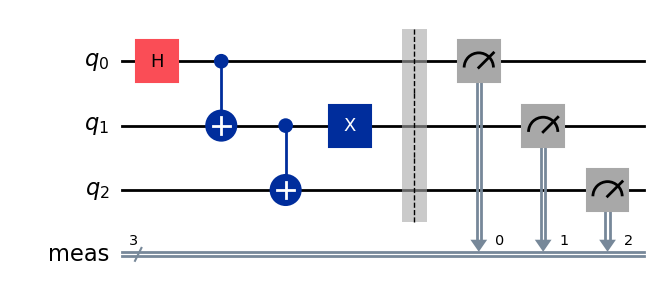

In [26]:
sampler = StatevectorSampler()
result = sampler.run([qc], shots=pow(2,10)).result()
print(result[0].data.meas.get_counts())
qc.draw("mpl")

In [27]:
import matplotlib.pyplot as plt
from qiskit.visualization import plot_histogram


In [28]:
counts = result[0].data.meas.get_counts()
plot_histogram(counts)
plt.show()

In [29]:
from qiskit.circuit.library import zz_feature_map

In [30]:
features = [0.2, 0.4, 0.8]
feature_map = zz_feature_map(feature_dimension=len(features))

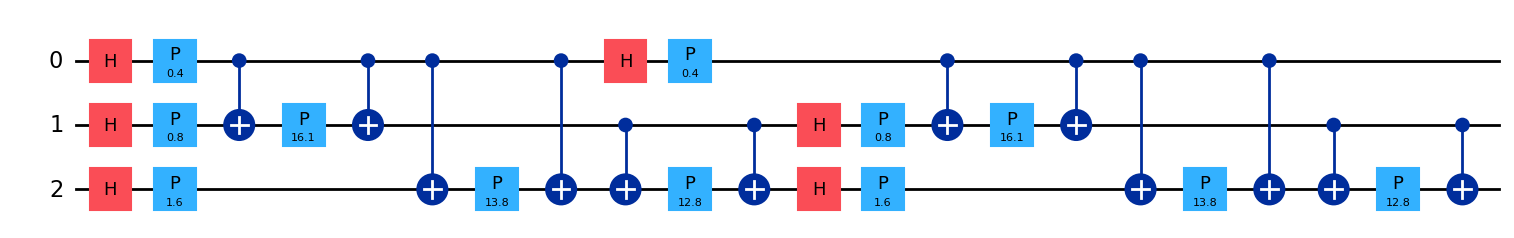

In [31]:
encoded = feature_map.assign_parameters(features)
encoded.draw("mpl")

In [32]:
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_ibm_runtime.fake_provider import FakeAuckland, FakeWashingtonV2
from qiskit.transpiler import generate_preset_pass_manager


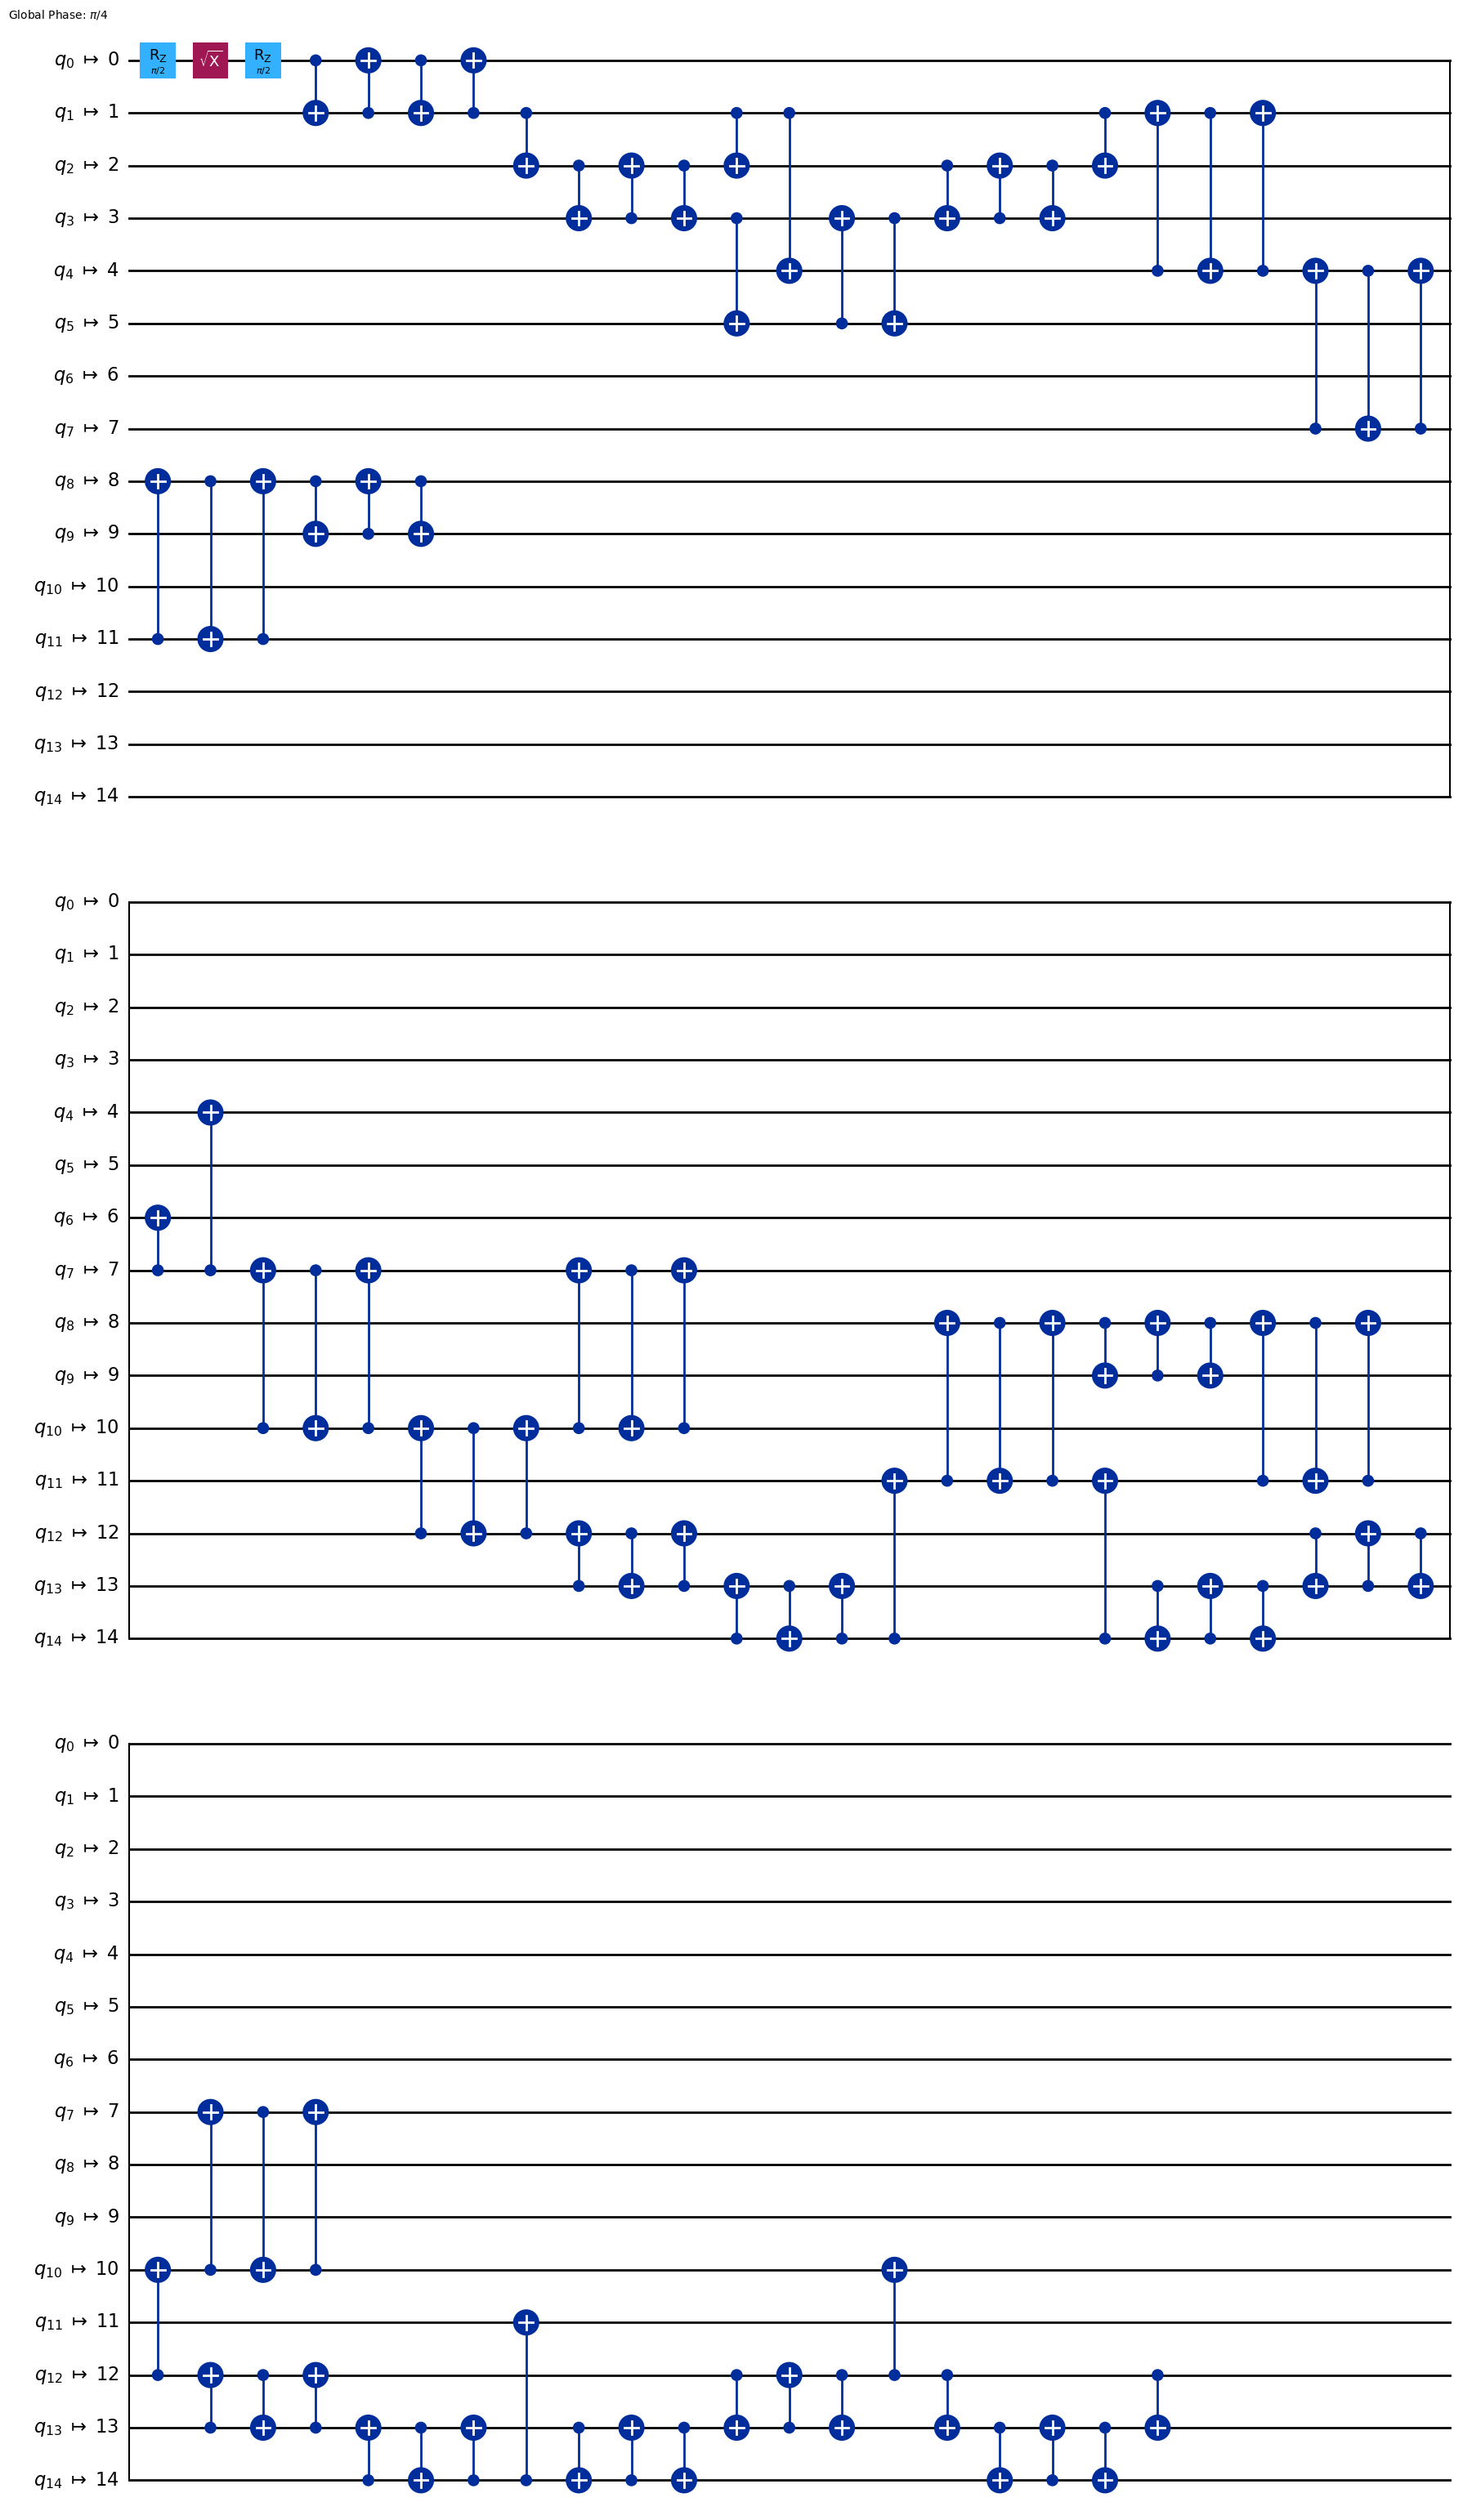

In [33]:
backend = FakeAuckland()
ghz = QuantumCircuit(15)
ghz.h(0)
ghz.cx(0, range(1, 15))
depths = []
for seed in range(100):
    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        layout_method="trivial", # Fixed layout mapped in circuit order
        seed_transpiler=seed, # For reproducible results
    )
    depths.append(pass_manager.run(ghz).depth())

pass_manager.run(ghz).draw("mpl")

# plt.figure(figsize=(8, 6))
# plt.hist(depths, align="left", color="#AC557C")
# plt.xlabel("Depth", fontsize=14)
# plt.ylabel("Counts", fontsize=14)

In [34]:
from qiskit import QuantumCircuit
from qiskit.circuit import QuantumCircuit, Parameter



In [35]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0,1)
circuit.ry(0,0,"a")
circuit.measure_all()

In [36]:
from qiskit.circuit import QuantumCircuit, Parameter
from qiskit_aer.primitives import SamplerV2


In [37]:

# create the parameter
phi = Parameter('phi')
params = [0.1] * circuit.num_parameters
pub = (circuit, params, 1024)
sampler = SamplerV2()
job = sampler.run([pub])
result = job.result()

In [38]:
data = result[0].data
print(f"Databin: {data}\n")
# to access the BitArray, use the key "meas", which is the default name of
# the classical register when this is added by the `measure_all` method
array = data.meas
print(f"BitArray: {array}\n")
print(f"The shape of register `meas` is {data.meas.array.shape}.\n")
print(f"The bytes in register `alpha`, shot by shot:\n{data.meas.array}\n")
# optionally, convert away from the native BitArray format to a dictionary format
counts = data.meas.get_counts()
print(f"Counts: {counts}")

Databin: DataBin(meas=BitArray(<shape=(), num_shots=1024, num_bits=2>))

BitArray: BitArray(<shape=(), num_shots=1024, num_bits=2>)

The shape of register `meas` is (1024, 1).

The bytes in register `alpha`, shot by shot:
[[0]
 [0]
 [3]
 ...
 [3]
 [3]
 [3]]

Counts: {'00': 510, '11': 514}


In [39]:
from qiskit.circuit.library import efficient_su2
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_aer.primitives import EstimatorV2 as Estimator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import SamplerV2


In [40]:


n_qubits = 8
circuit = efficient_su2(n_qubits)
circuit.measure_all()
circuit.draw("mpl")
observable = SparsePauliOp("Z" * n_qubits)
params = [0.1] * circuit.num_parameters

exact_estimator = SamplerV2()
# The circuit needs to be transpiled to the AerSimulator target
pass_manager = generate_preset_pass_manager(3, AerSimulator())
isa_circuit = pass_manager.run(circuit)
pub = (isa_circuit, params)
job = exact_estimator.run([pub],shots=1024)
result = job.result()
counts_ideal = result[0].data.meas.get_counts()
counts_ideal
# to access the BitArray, use the key "meas", which is the default name of
# the classical register when this is added by the `measure_all` method


{'00000000': 907,
 '00111100': 8,
 '11110000': 8,
 '01010000': 1,
 '10100000': 6,
 '10000000': 39,
 '00011110': 4,
 '11000000': 9,
 '00100000': 5,
 '00000110': 2,
 '01000000': 3,
 '00001100': 2,
 '11100000': 4,
 '00001111': 3,
 '10010000': 2,
 '00011000': 2,
 '01111000': 2,
 '00000010': 1,
 '01100000': 1,
 '01001111': 1,
 '00000011': 1,
 '00000001': 2,
 '00101000': 2,
 '00001000': 1,
 '00110000': 1,
 '00010100': 2,
 '10101111': 1,
 '10001010': 1,
 '00000100': 1,
 '00010000': 1,
 '10101000': 1}

In [41]:
noise_model = NoiseModel()
cx_depolarizing_prob = 0.02
noise_model.add_all_qubit_quantum_error(
depolarizing_error(cx_depolarizing_prob, 2), ["cx"])

noisy_estimator = SamplerV2(
options=dict(backend_options=dict(noise_model=noise_model)))
job = noisy_estimator.run([pub])
result = job.result()
counts_ideal = result[0].data.meas.get_counts()
counts_ideal

{'00001100': 17,
 '00010100': 16,
 '00000000': 685,
 '10011000': 1,
 '00010000': 11,
 '10000000': 16,
 '00100000': 14,
 '00000001': 6,
 '00000101': 3,
 '00111100': 6,
 '00101000': 11,
 '00010010': 2,
 '00001000': 12,
 '00011100': 3,
 '00001010': 10,
 '10000100': 1,
 '11000000': 22,
 '00000011': 5,
 '00111000': 2,
 '01000000': 26,
 '00000010': 6,
 '00001111': 9,
 '00011110': 3,
 '10100000': 13,
 '01000100': 2,
 '01100000': 7,
 '00011000': 13,
 '01111000': 3,
 '10001111': 1,
 '11010000': 3,
 '00011010': 1,
 '00110010': 1,
 '10001010': 1,
 '00110000': 9,
 '11000100': 1,
 '01010000': 11,
 '11100000': 8,
 '11110000': 4,
 '01001000': 2,
 '00000110': 10,
 '10101000': 1,
 '00010101': 1,
 '00001011': 1,
 '00000100': 14,
 '10010000': 1,
 '00011101': 1,
 '10010100': 2,
 '00111110': 1,
 '01001010': 1,
 '01010100': 1,
 '10011110': 1,
 '01011100': 2,
 '11110100': 2,
 '11001010': 1,
 '01101100': 1,
 '11010100': 1,
 '00111010': 1,
 '11000110': 1,
 '00101100': 1,
 '00001101': 1,
 '01011000': 1,
 '11111

In [42]:
import pennylane as qml
from jax import numpy as np
import jax

In [43]:
dev1 = qml.device("default.qubit", wires=4)

In [44]:
def circuit(params):
    qml.RX(params[0], wires=0)
    qml.RY(params[1], wires=0)
    return qml.expval(qml.PauliZ(0))
params = np.array([0.54, 0.12])
print(circuit(params))

expval(Z(0))
